# Copy number normalization
March 4, 2024

Attempt to normalize by nucleosome read counts, (collect the normalization count) to see if the deconvolved chromatin profile is approximately stationary for non-cell cycling genes.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_model import load_chromatin_model_from_disk

chromatin_dir = 'output/deconvolve_rep1_g006_2024_02_20/chromatin/'

In [3]:
gene_name = 'SSK22'
chromatin_model_ssk22 = load_chromatin_model_from_disk(gene_name, chromatin_dir)

Loading MNase reads for YCR073C/SSK22...Loading chromosome reads: 3
Done.


In [4]:
# let's compare to the old, unnormalized deconvolution profile:
chromatin_model_ssk22.create_deconvolution_bins()
chromatin_model_ssk22.deconvolve(verbose=False)
chromatin_model_ssk22.compute_ptr()

Deconvolving with gamma=0.006, gamma_prime=0
Deconvolved in : 00:01:53.04
The fitting norm is 4.39, the smoothing norm is: 8.51


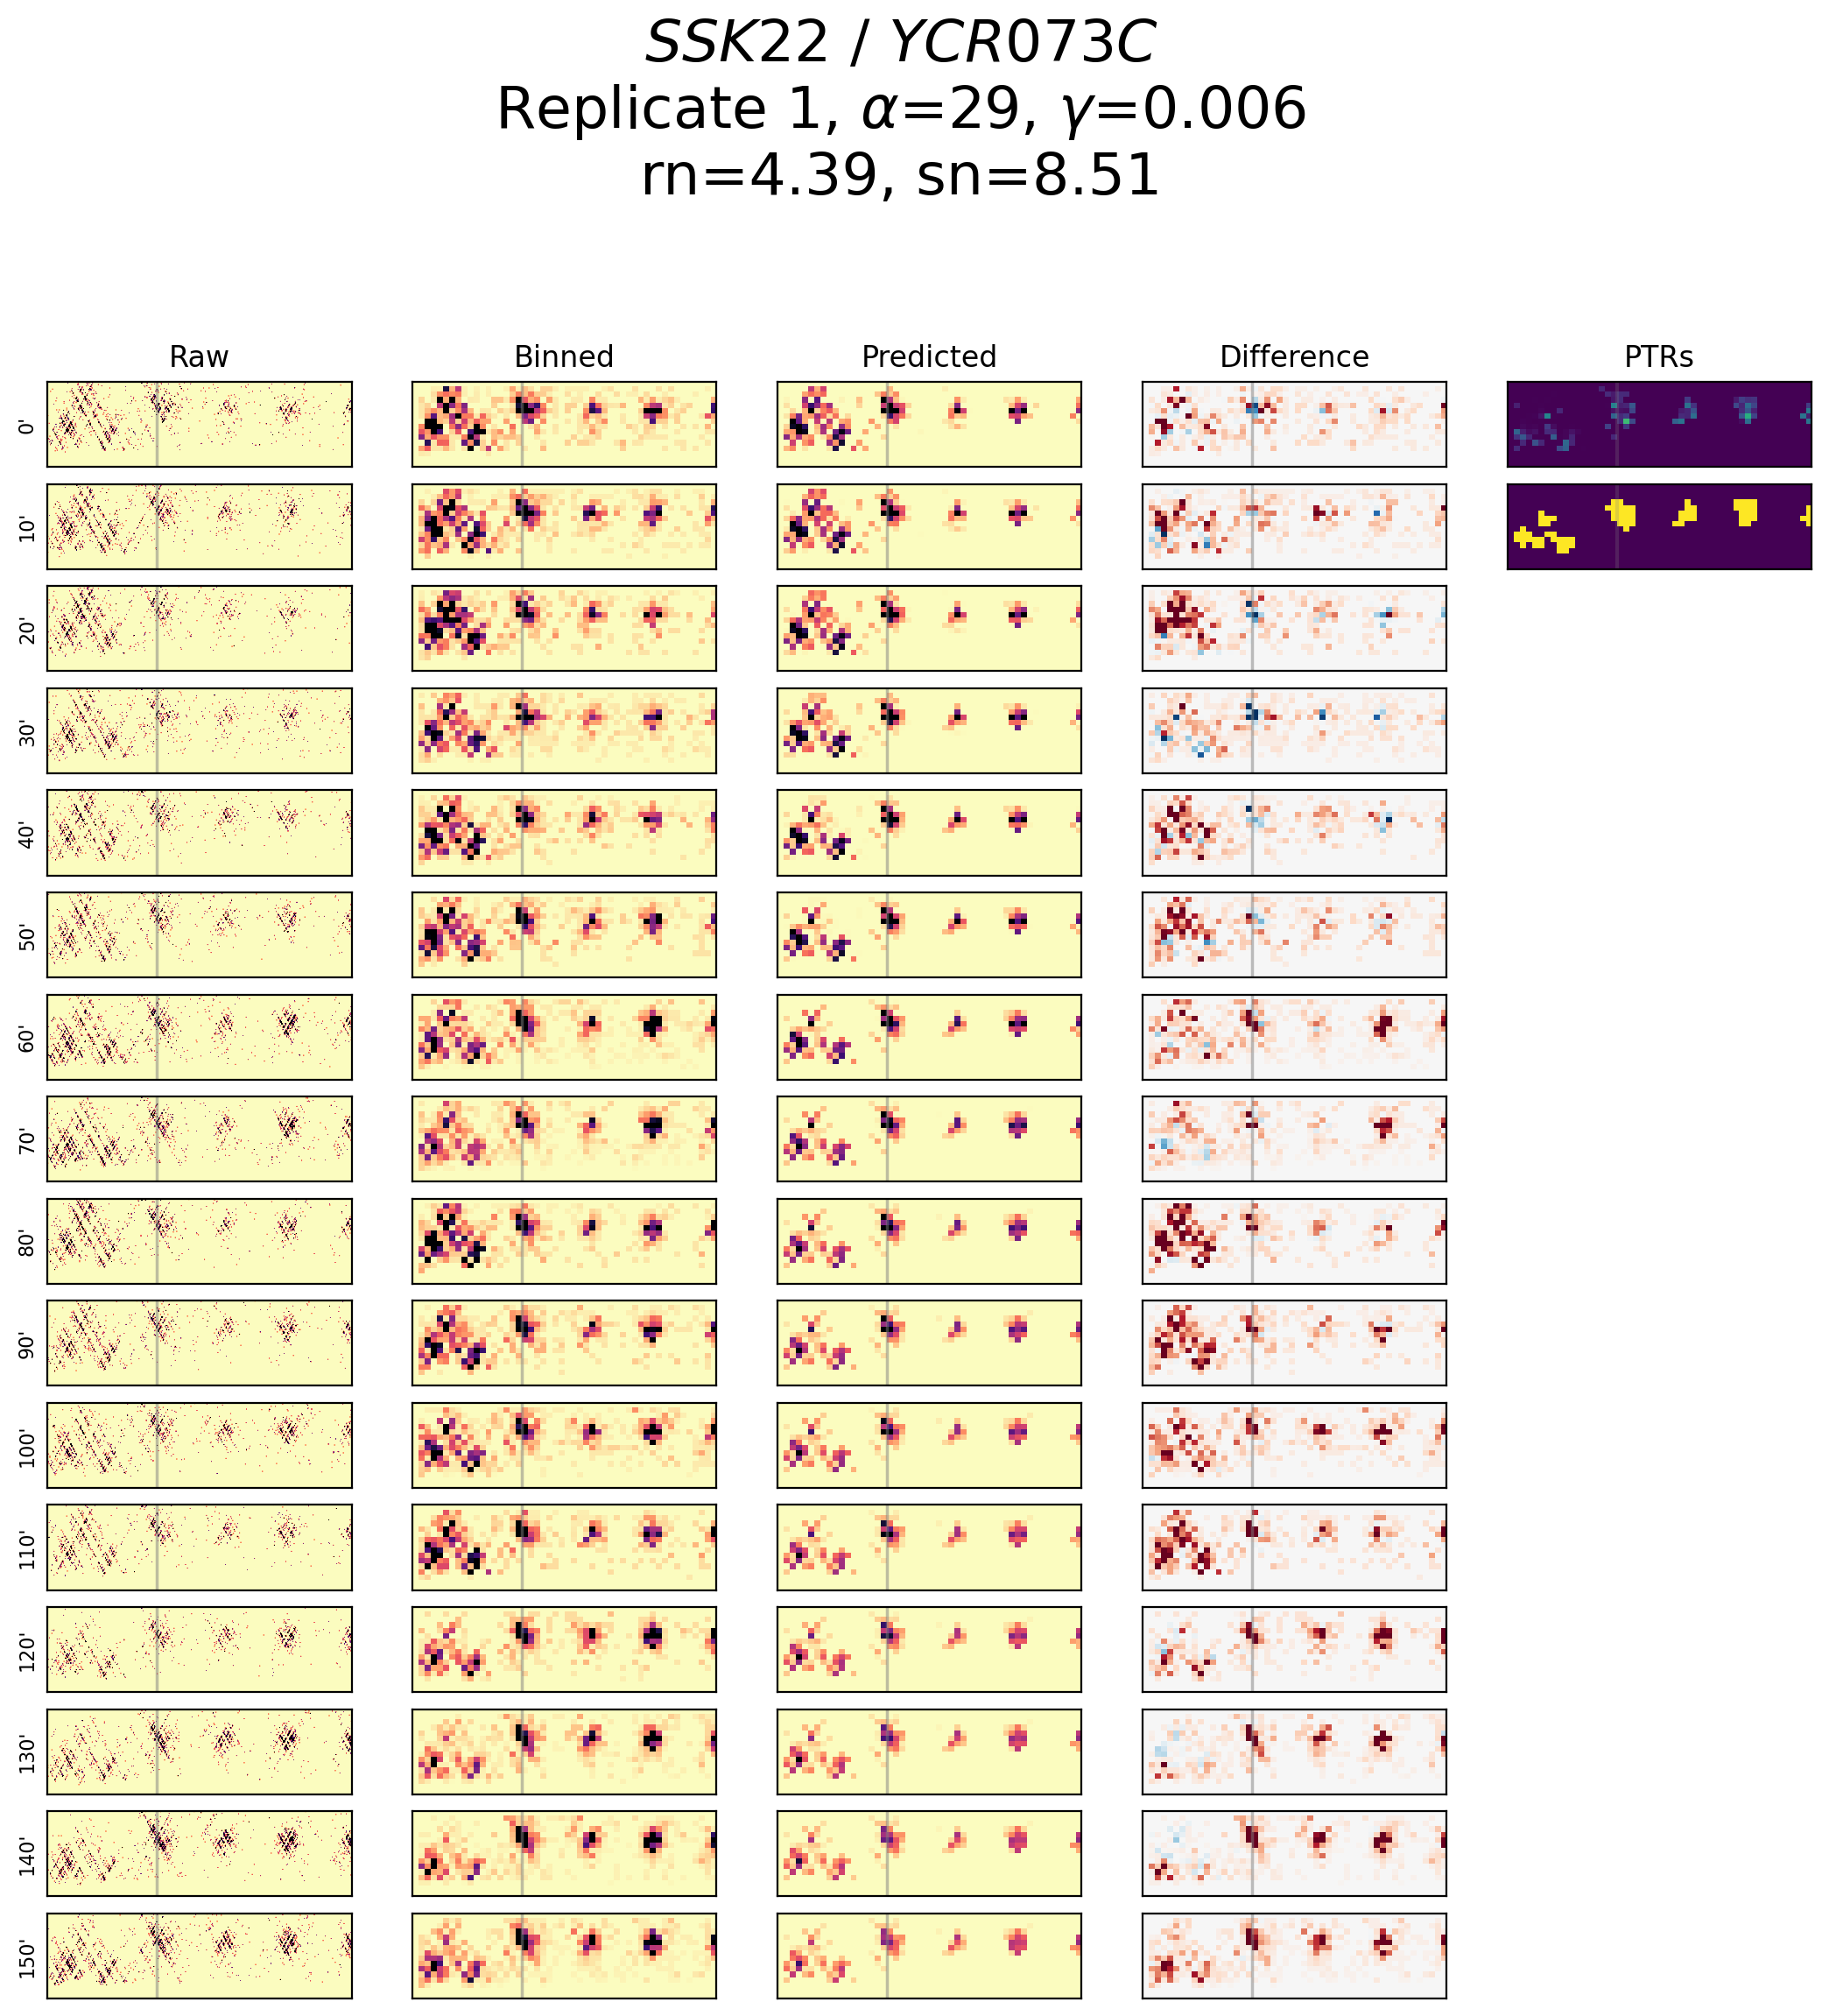

In [7]:
fig = chromatin_model_ssk22.plot_prediction_comparison()

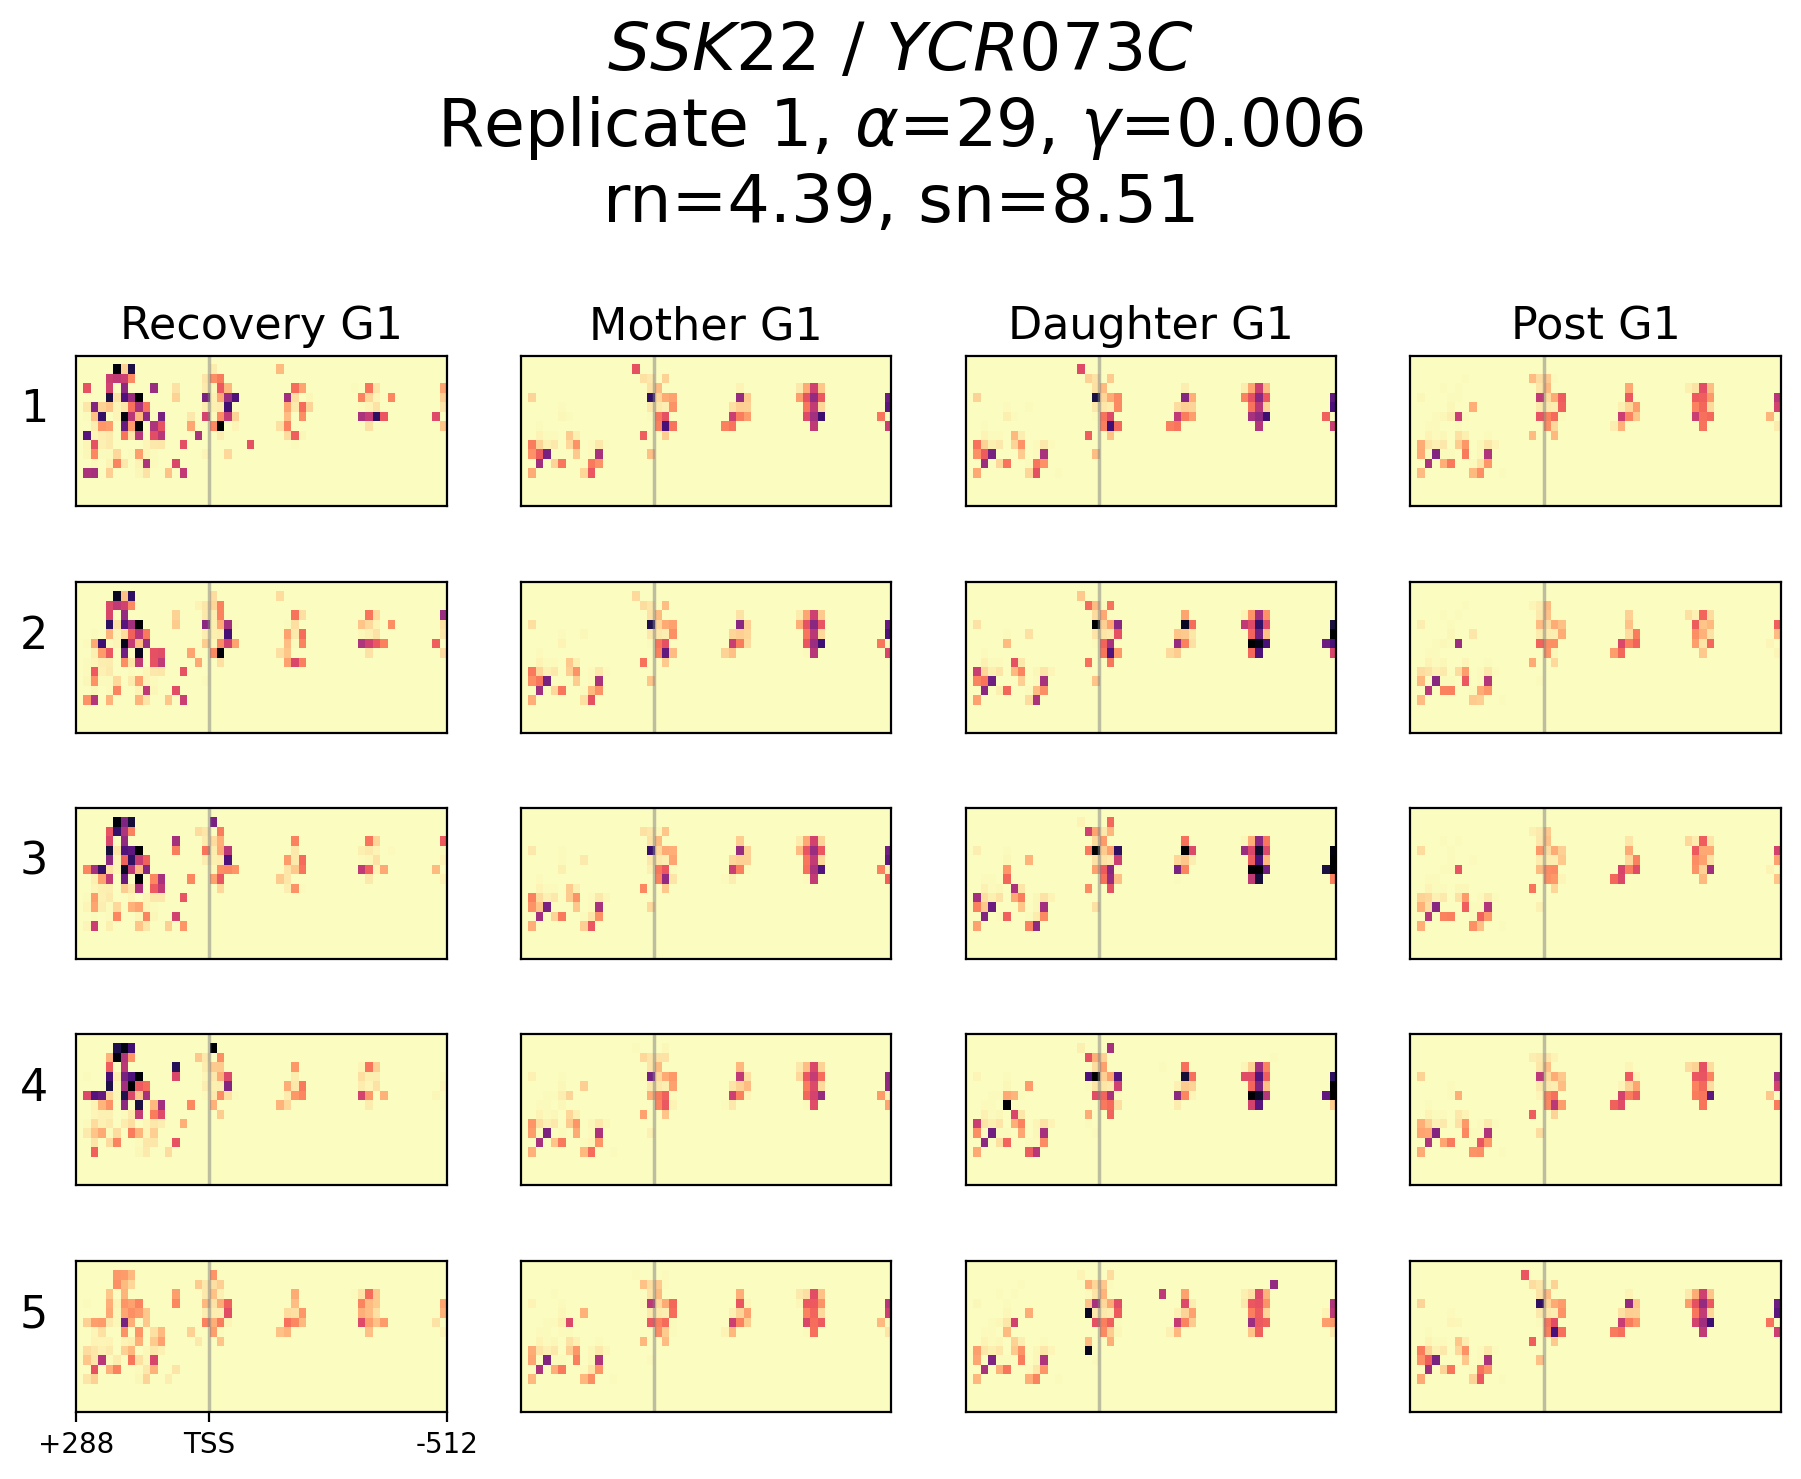

In [8]:
fig = chromatin_model_ssk22.create_deconvolution_plots_abbreviated_flipped()

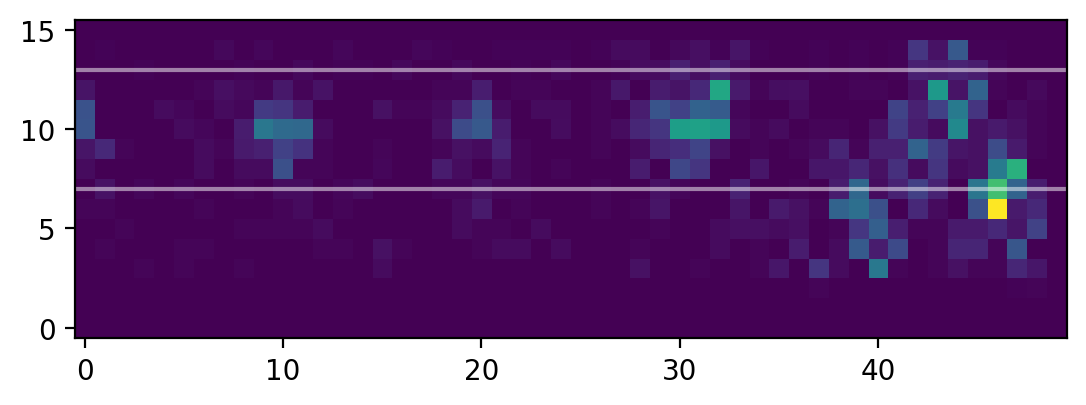

In [72]:
# Plot a region for the nucleosome counts for G and F
# Count up the number of fragments for this window for G and F
# Normalize these counts so they are even for the entire time course
# Deconvolve.
from cc_src.chromatin_metrics import yl_rep2_len_spans

img = chromatin_model_ssk22.deconv_hist_unflattened[0]
plt.imshow(img, origin='lower')

nuc_window = 125,220
nuc_window_bins = nuc_window[0]//16, nuc_window[1]//16
plt.axhline(nuc_window_bins[0], c='white', alpha=0.5)
plt.axhline(nuc_window_bins[1], c='white', alpha=0.5)

def get_nuc_read_count(img):
    nuc_window = yl_rep2_len_spans()[2]
    nuc_window_bins = nuc_window[0]//16, nuc_window[1]//16
    count = img[nuc_window_bins[0]:nuc_window_bins[1], :].sum()
    return count


In [73]:

imgs = chromatin_model_ssk22.deconv_hist_unflattened

def get_nuc_counts(imgs):
    counts = []
    for i in range(imgs.shape[0]):
        counts.append(get_nuc_read_count(imgs[i]))
    counts = np.array(counts)
    return counts

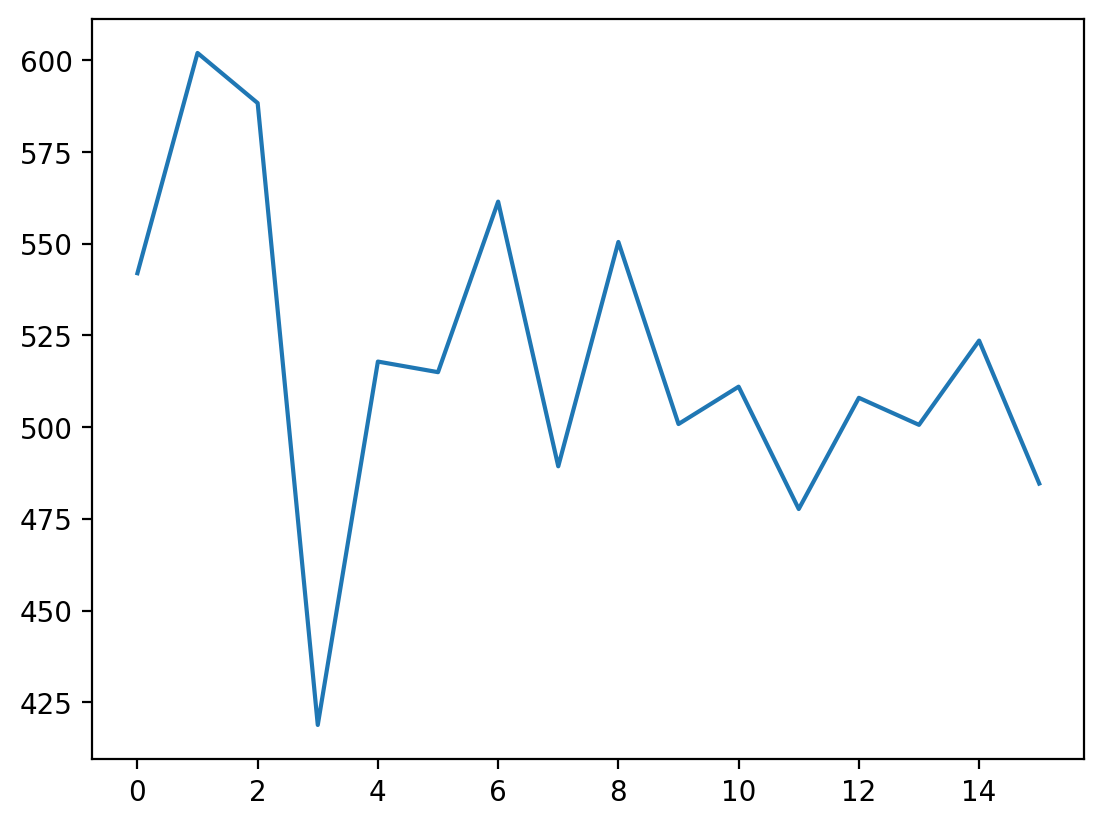

In [74]:
counts = get_nuc_counts(imgs)
plt.plot(counts)

In [75]:
# Let's now normalize the G images such that these nucleosome counts are equivalent.
imgs_normalized = imgs.copy()

for i in range(imgs.shape[0]):
    imgs_normalized[i] = imgs[i] / counts[i] * 500

In [76]:
chromatin_model_ssk22.G = imgs_normalized.reshape((imgs_normalized.shape[0], -1))
chromatin_model_ssk22.deconvolve(verbose=False)
chromatin_model_ssk22.compute_ptr()

Deconvolving with gamma=0.006, gamma_prime=0
Deconvolved in : 00:01:36.35
The fitting norm is 4.38, the smoothing norm is: 8.59


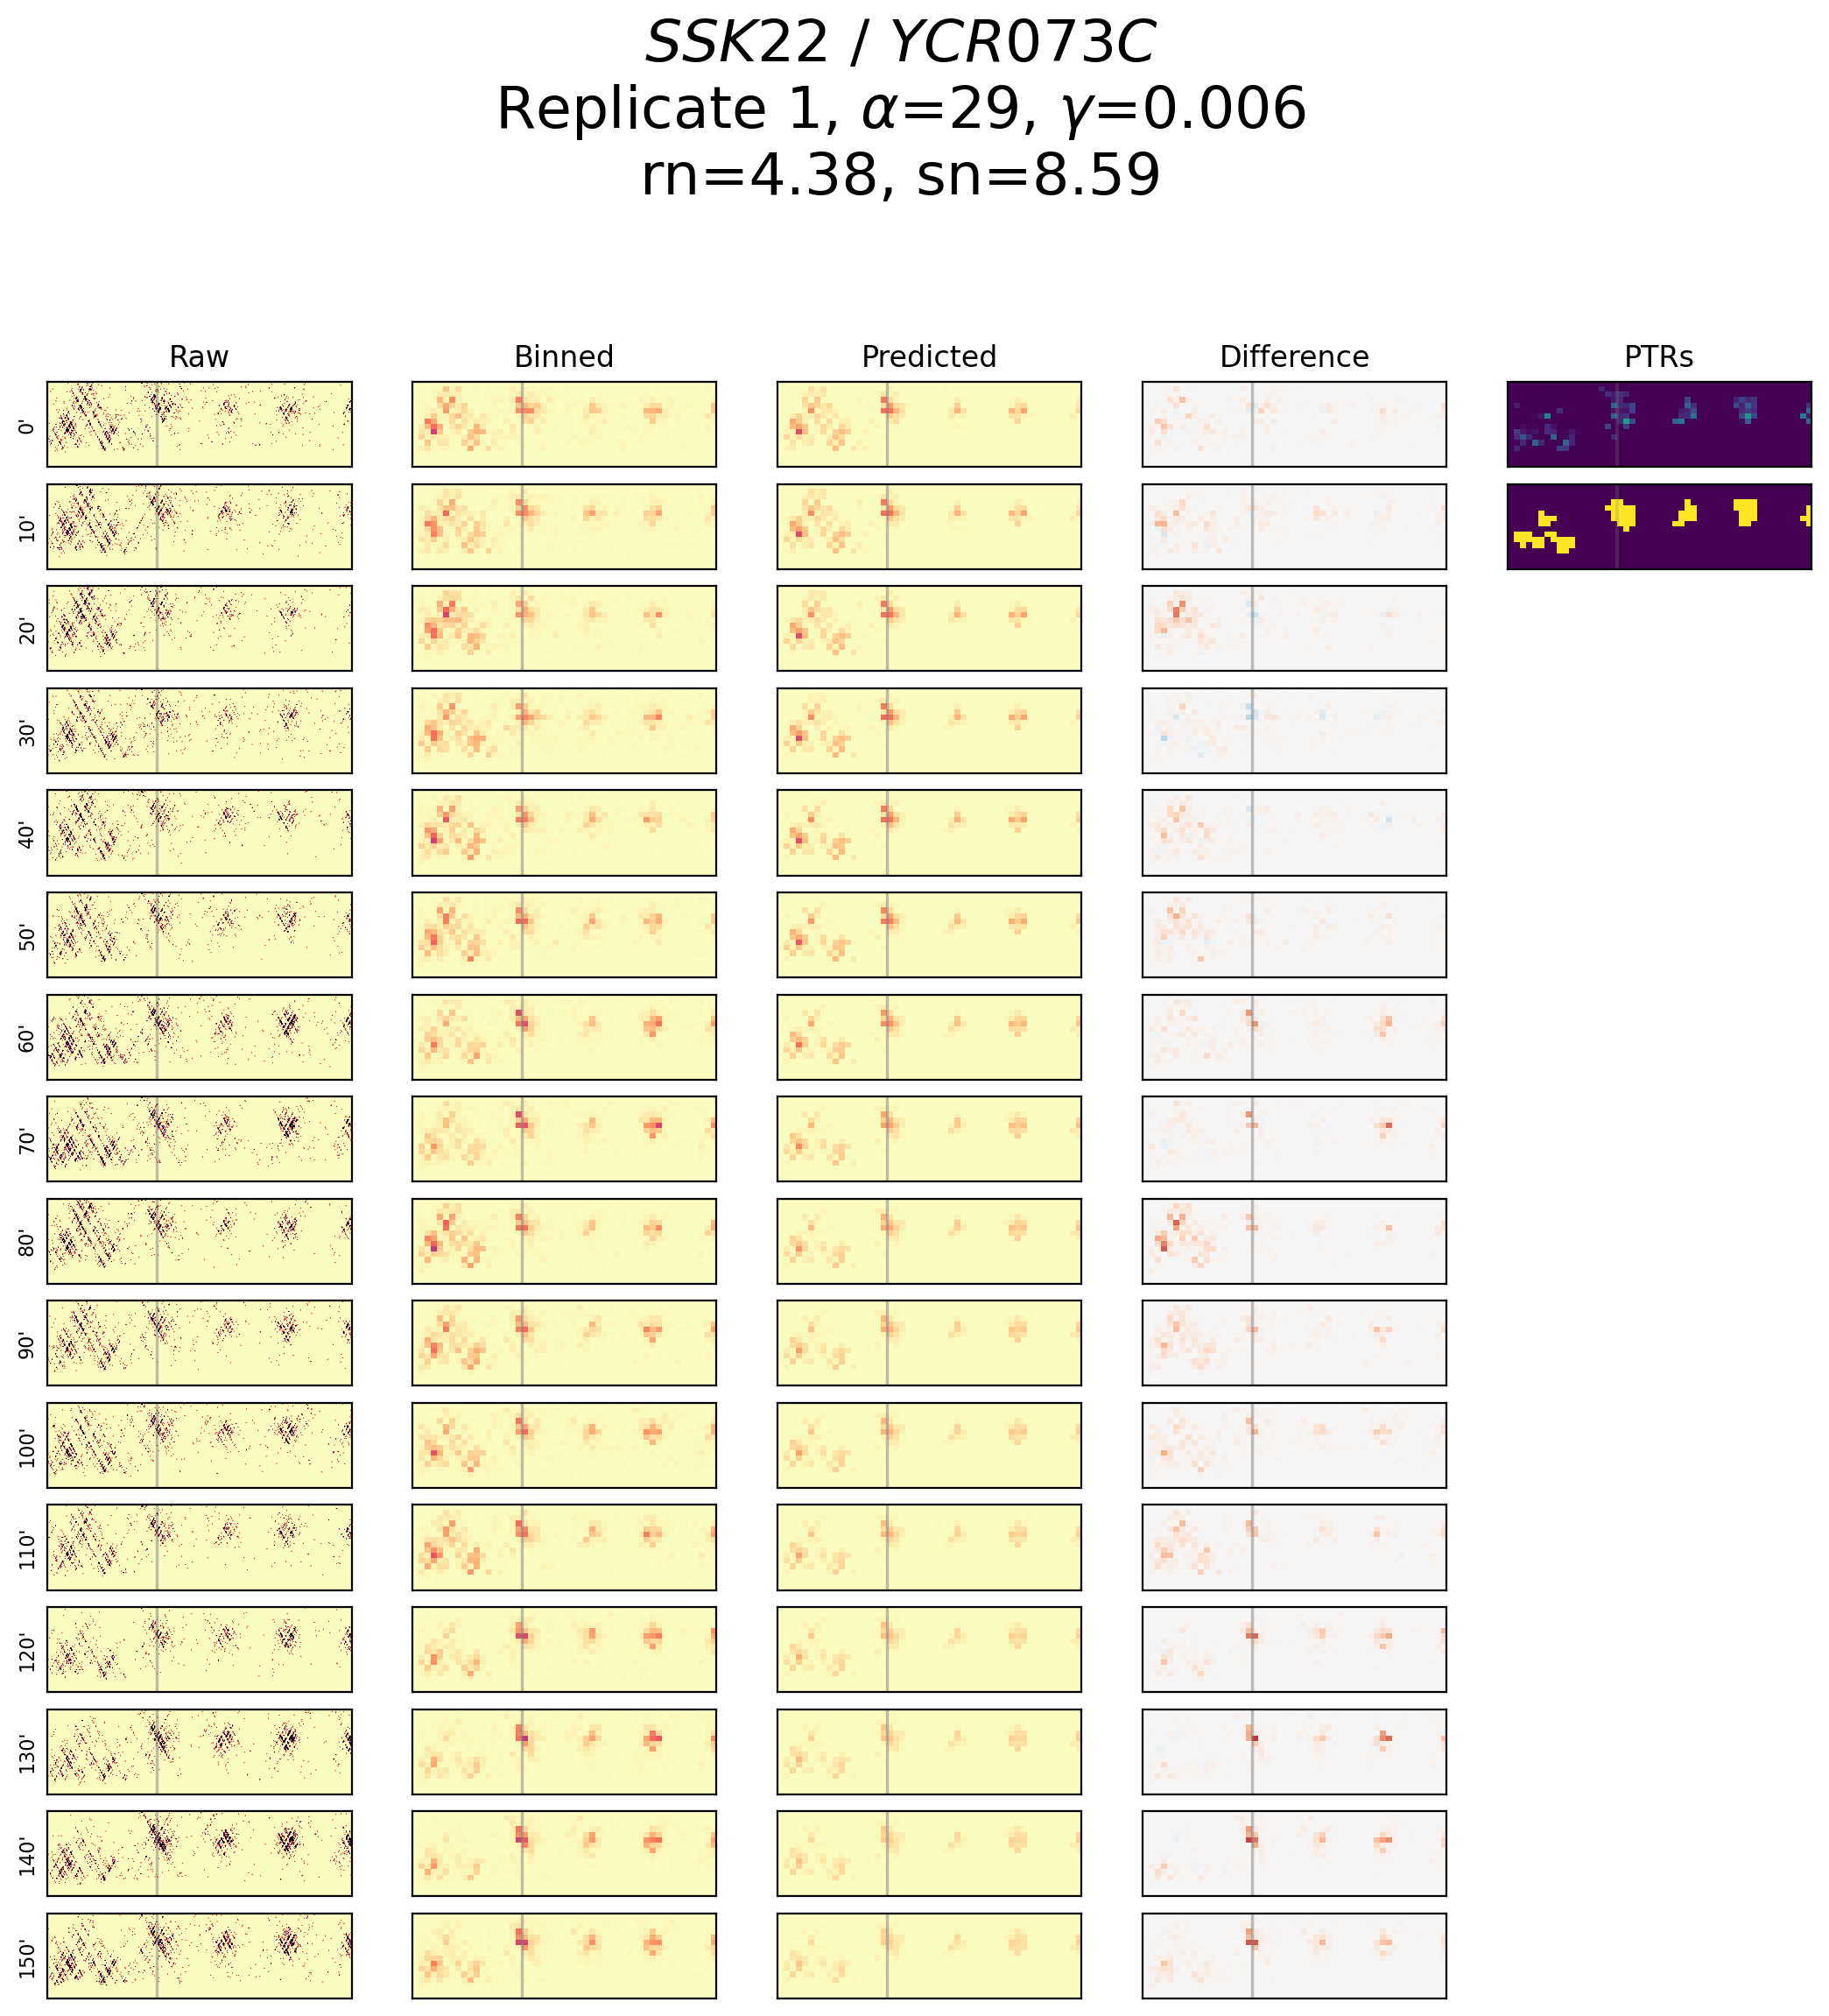

In [80]:
fig = chromatin_model_ssk22.plot_prediction_comparison(vmax=100)

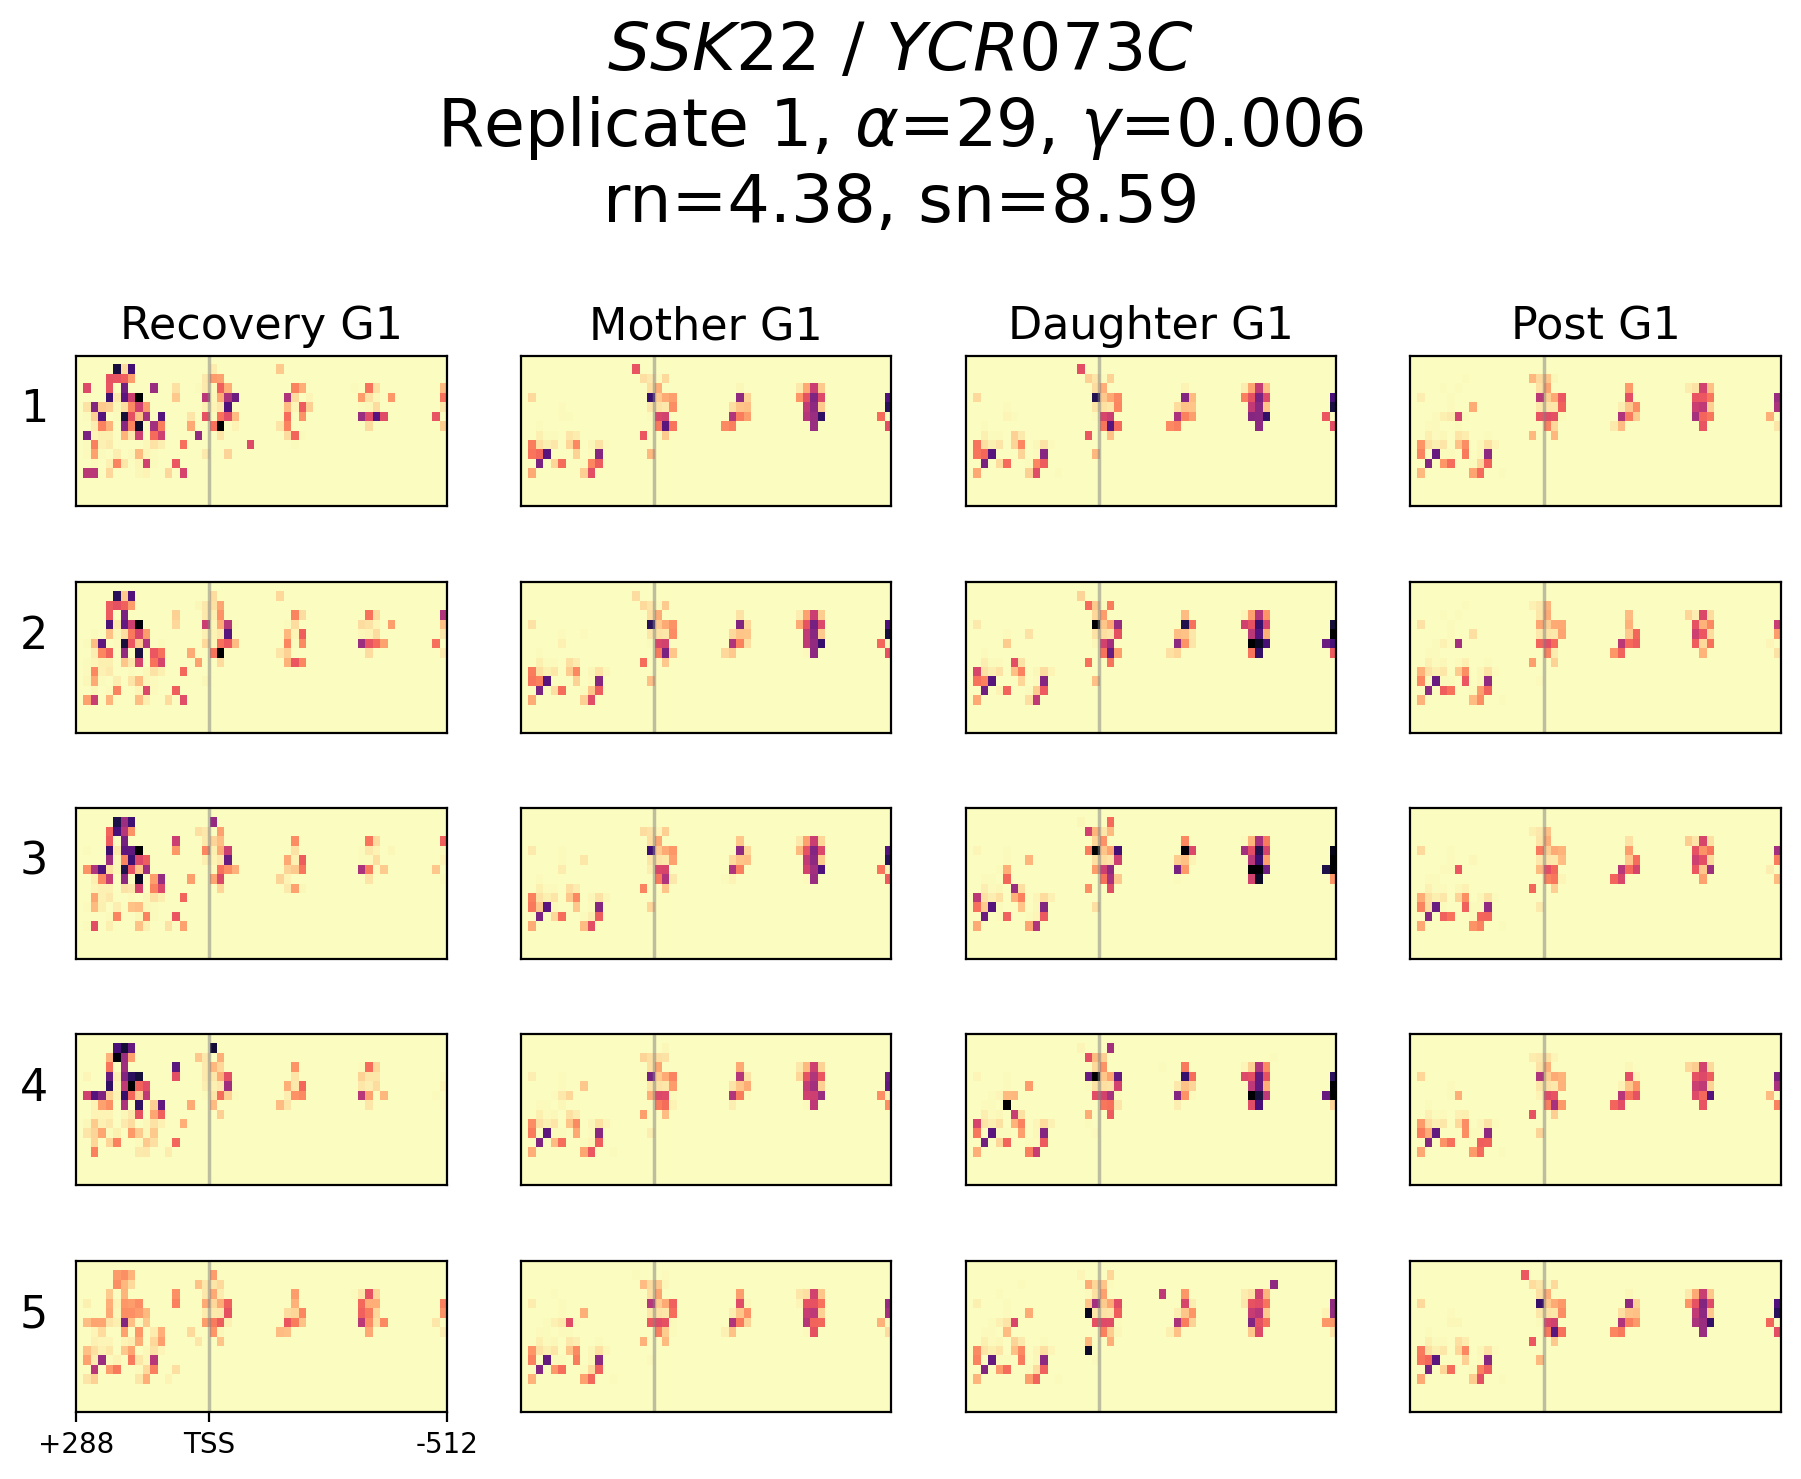

In [78]:
fig = chromatin_model_ssk22.create_deconvolution_plots_abbreviated_flipped()